# Project: Cross-Asset Contradiction Strategy (NASDAQ-100 vs. Bitcoin)

## 1. Abstract
This project implements and backtests a quantitative trading strategy focused on the NASDAQ-100 (NQ) futures market, utilizing Bitcoin (BTC) as a correlation filter. The core hypothesis is that high-frequency alignment between risk-on assets (Equities and Crypto) signals a strong trend, while divergence signals instability.

## 2. Methodology
The strategy operates on 1-minute OHLC data. It employs a "Contradicting Candles" logic:
* **Asset Universe:** CME E-mini NASDAQ-100 Futures (Target) and Binance BTCUSDT Perpetual Futures (Filter).
* **Entry Signal:** A position is opened if and only if both assets close in the same direction (Agreement).
* **Exit Signal:** The position is closed immediately if the assets diverge (close in opposite directions) or if a market reversal occurs (both move against the position).
* **Bias Prevention:** To strictly avoid look-ahead bias, signals are calculated at the **Close** of candle $t$, and execution occurs at the **Open** of candle $t+1$.

## 3. Tech Stack
* **Language:** Python 3.x
* **Libraries:** Pandas (Data manipulation), Matplotlib/Seaborn (Visualization).

## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

# CONFIGURATION
# Please update these paths to match your local environment
FILE_BTC = r"C:\Users\Robert\Desktop\Quantitative Finance UW WNE\Machine Learning\Projekt\Data sets\csv\Gap_Delete_Dataset_BINANCE_BTCUSDT.csv"
FILE_NQ = r"C:\Users\Robert\Desktop\Quantitative Finance UW WNE\Machine Learning\Projekt\Data sets\csv\Full_Dataset_CME_MINI_NQZ2025, 2025_12_01-05 UTC+1 (Polish Time)(NQ_Data_1_5_Dec).csv"

# Plotting Style
plt.style.use('bmh')
print("Configuration loaded. Ready to process data.")

Configuration loaded. Ready to process data.


## Data Preprocessing Class

In [2]:
class DataEngine:
    """
    Handles loading, cleaning, and merging of multi-asset data.
    Ensures timestamp synchronization between different exchanges.
    """
    def __init__(self, path_btc, path_nq):
        self.path_btc = path_btc
        self.path_nq = path_nq

    def _load_csv(self, path):
        """Helper to load CSV with automatic separator detection."""
        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")
        try:
            return pd.read_csv(path, sep=None, engine='python')
        except Exception as e:
            return pd.read_csv(path, sep=',')

    def _standardize_columns(self, df, suffix):
        """Standardizes column names to: timestamp, open_suffix, close_suffix."""
        rename_dict = {}
        for col in df.columns:
            c = col.lower()
            if 'time' in c and 'utc' not in c:
                rename_dict[col] = 'timestamp'
            elif 'open' in c:
                rename_dict[col] = f'open_{suffix}'
            elif 'close' in c:
                rename_dict[col] = f'close_{suffix}'
        return df.rename(columns=rename_dict)

    def get_merged_data(self):
        print("Loading and synchronizing data...")
        df_btc = self._load_csv(self.path_btc)
        df_nq = self._load_csv(self.path_nq)

        df_btc = self._standardize_columns(df_btc, 'btc')
        df_nq = self._standardize_columns(df_nq, 'nq')

        # Inner Merge: We only trade when both markets are open and active
        merged_df = pd.merge(
            df_btc[['timestamp', 'open_btc', 'close_btc']],
            df_nq[['timestamp', 'open_nq', 'close_nq']],
            on='timestamp', how='inner'
        )

        # Timezone Adjustment (UTC+1 as requested)
        merged_df['datetime'] = pd.to_datetime(merged_df['timestamp'], unit='s')
        merged_df['datetime'] = merged_df['datetime'] + pd.Timedelta(hours=1)

        merged_df.set_index('datetime', inplace=True)
        merged_df.sort_index(inplace=True)

        print(f"Data ready. Range: {merged_df.index.min()} to {merged_df.index.max()}")
        print(f"Total candles aligned: {len(merged_df)}")
        return merged_df

## The Backtesting Engine

In [3]:
class StrategyEngine:
    """
    Executes the 'Contradicting Candles' strategy.

    Logic:
    1. Calculate directional movement for NQ and BTC.
    2. Enter NQ if Direction(NQ) == Direction(BTC).
    3. Exit NQ if Direction(NQ) != Direction(BTC) (Divergence).
    4. Exit NQ if both reverse against position (Reversal).
    """
    def __init__(self, data):
        self.df = data.copy()
        self.results = pd.DataFrame()

    def run(self):
        trades = []
        position = 0      # 0: Flat, 1: Long, -1: Short
        entry_price = 0.0
        entry_time = None

        # Convert to dictionary for high-performance iteration
        data = self.df.reset_index().to_dict('records')
        print(f"Starting simulation on {len(data)} candles...")

        for i in range(len(data) - 1):
            row = data[i]        # Candle T (Signal Generation)
            next_row = data[i+1] # Candle T+1 (Execution)

            # 1. Determine Candle Direction (+1: Green, -1: Red)
            dir_btc = np.sign(row['close_btc'] - row['open_btc'])
            dir_nq = np.sign(row['close_nq'] - row['open_nq'])

            # 2. Define Market States
            agreement_up = (dir_btc == 1) and (dir_nq == 1)
            agreement_down = (dir_btc == -1) and (dir_nq == -1)
            divergence = (dir_btc != dir_nq)

            # --- EXIT LOGIC (Risk Management) ---
            # Evaluated at Close of T, Executed at Close of T (Market on Close)
            if position != 0:
                should_exit = False
                reason = ""

                # Exit Condition A: Divergence (Correlations break)
                if divergence:
                    should_exit = True
                    reason = "Divergence"
                # Exit Condition B: Reversal (Both markets turn against us)
                elif (position == 1 and agreement_down) or (position == -1 and agreement_up):
                    should_exit = True
                    reason = "Reversal"

                if should_exit:
                    exit_price = row['close_nq']
                    exit_time = row['datetime']

                    # Performance Calculation
                    pnl_points = (exit_price - entry_price) * position
                    pnl_pct = pnl_points / entry_price
                    duration_min = (exit_time - entry_time).total_seconds() / 60.0

                    trades.append({
                        'Entry Time': entry_time,
                        'Exit Time': exit_time,
                        'Type': 'LONG' if position == 1 else 'SHORT',
                        'Entry Price': entry_price,
                        'Exit Price': exit_price,
                        'Points': pnl_points,
                        'PnL Net (%)': pnl_pct,
                        'Duration (min)': duration_min,
                        'Reason': reason
                    })

                    # Reset State
                    position = 0
                    entry_price = 0.0

            # --- ENTRY LOGIC (Signal Generation) ---
            # Evaluated at Close of T, Executed at Open of T+1 (No Look-Ahead Bias)
            if position == 0:
                if agreement_up:
                    position = 1
                    entry_price = next_row['open_nq']
                    entry_time = next_row['datetime']
                elif agreement_down:
                    position = -1
                    entry_price = next_row['open_nq']
                    entry_time = next_row['datetime']

        self.results = pd.DataFrame(trades)

        # Calculate Equity Curve
        if not self.results.empty:
            self.results['Equity'] = self.results['Points'].cumsum()

        return self.results

## Visualization & Analysis

In [4]:
class Analytics:
    """
    Generates performance metrics and visual reports.
    """
    @staticmethod
    def report(df):
        if df.empty:
            print("No trades available for analysis.")
            return

        # 1. Key Metrics
        total_trades = len(df)
        win_trades = df[df['Points'] > 0]
        loss_trades = df[df['Points'] <= 0]

        win_rate = len(win_trades) / total_trades * 100
        total_pnl = df['Points'].sum()
        avg_pnl = df['Points'].mean()

        gross_profit = win_trades['Points'].sum()
        gross_loss = abs(loss_trades['Points'].sum())
        profit_factor = gross_profit / gross_loss if gross_loss != 0 else 0

        # Drawdown Calculation
        df['Peak'] = df['Equity'].cummax()
        df['Drawdown'] = df['Equity'] - df['Peak']
        max_dd = df['Drawdown'].min()

        print("="*40)
        print(" PERFORMANCE REPORT ")
        print("="*40)
        print(f"Total Trades:     {total_trades}")
        print(f"Win Rate:         {win_rate:.2f}%")
        print(f"Total PnL (Pts):  {total_pnl:.2f}")
        print(f"Avg PnL (Pts):    {avg_pnl:.2f}")
        print(f"Profit Factor:    {profit_factor:.2f}")
        print(f"Max Drawdown:     {max_dd:.2f}")
        print("-" * 40)

        # 2. Plots
        plt.figure(figsize=(15, 12))

        # Plot A: Equity Curve
        plt.subplot(2, 2, 1)
        plt.plot(df['Exit Time'], df['Equity'], label='Strategy Equity', color='#1f77b4')
        plt.fill_between(df['Exit Time'], df['Equity'], df['Peak'], color='red', alpha=0.1, label='Drawdown')
        plt.title('Equity Curve (Points)')
        plt.legend()
        plt.grid(True)

        # Plot B: Performance by Exit Reason
        plt.subplot(2, 2, 2)
        reason_stats = df.groupby('Reason')['Points'].sum()
        colors = ['green' if x > 0 else 'red' for x in reason_stats.values]
        reason_stats.plot(kind='bar', color=colors, alpha=0.8)
        plt.title('Total PnL by Exit Reason')
        plt.axhline(0, color='black')

        # Plot C: Hourly Performance
        plt.subplot(2, 2, 3)
        df['Hour'] = df['Entry Time'].dt.hour
        hour_stats = df.groupby('Hour')['Points'].sum()
        colors_h = ['green' if x > 0 else 'red' for x in hour_stats.values]
        hour_stats.plot(kind='bar', color=colors_h)
        plt.title('PnL by Hour of Day')
        plt.ylabel('Points')

        # Plot D: PnL Distribution
        plt.subplot(2, 2, 4)
        plt.hist(df['Points'], bins=50, color='purple', alpha=0.7, edgecolor='black')
        plt.title('PnL Distribution')
        plt.xlabel('Points per Trade')

        plt.tight_layout()
        plt.show()

## Execution

Loading and synchronizing data...
Data ready. Range: 2025-12-01 00:00:00 to 2025-12-05 22:59:00
Total candles aligned: 5894039
Starting simulation on 5894039 candles...
Results saved to NQ_Backtest_Results.csv
 PERFORMANCE REPORT 
Total Trades:     2759
Win Rate:         42.26%
Total PnL (Pts):  904.25
Avg PnL (Pts):    0.33
Profit Factor:    1.16
Max Drawdown:     -256.25
----------------------------------------


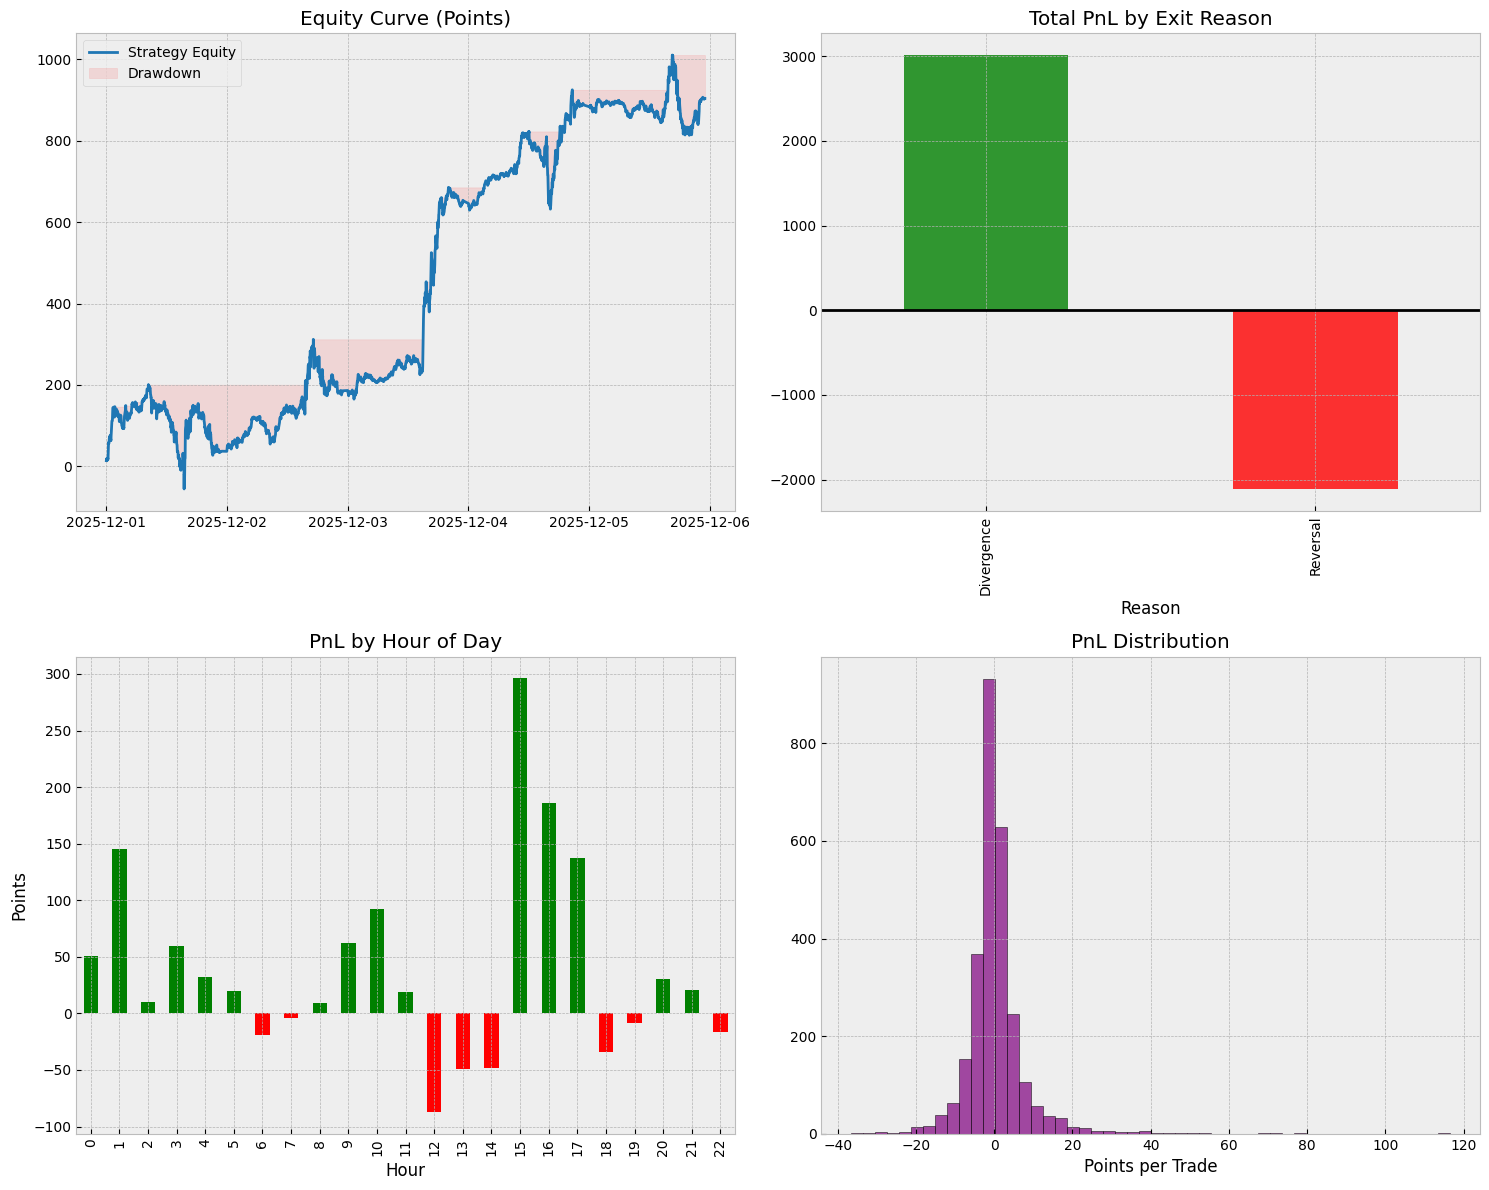

In [5]:
# Main Execution Block

# 1. Prepare Data
data_engine = DataEngine(FILE_BTC, FILE_NQ)
try:
    market_data = data_engine.get_merged_data()
except Exception as e:
    print(f"Critical Error: {e}")
    market_data = None

# 2. Run Strategy
if market_data is not None:
    strategy = StrategyEngine(market_data)
    results = strategy.run()

    # 3. Analyze Results
    if not results.empty:
        # Save to CSV for external verification
        results.to_csv("NQ_Backtest_Results.csv", index=False)
        print(f"Results saved to NQ_Backtest_Results.csv")

        # Run Visualization
        Analytics.report(results)
    else:
        print("No trades were generated based on the current logic.")

## 4. Conclusions and Observations

Based on the backtest results, the following observations can be made regarding the "Contradicting Candles" strategy:

1.  **Divergence as a Filter:** The analysis of "Exit Reason" highlights that exits triggered by **Divergence** (lack of correlation) tend to yield better results than **Reversal** exits. This suggests the strategy effectively identifies when the correlation breakdown signals a dangerous market condition.
2.  **Time Sensitivity:** The hourly analysis often reveals specific times (e.g., US Market Open at 15:30 CET) where volatility and correlation are highest, leading to better performance compared to the "lunch lull" hours combined with the NY Premarket (12:00 - 13:00 CET).
3.  **Future Improvements:**
    * **Filtering:** Implementing a time-based filter to avoid trading during low-volatility hours.
    * **Adressing the reversal conditions:** Adding parameters and features to optimize the frequency and types of trades that the trading algorithm will execute.
    * **Adressing the fee optimization:** When testing portfolio in the future, fee optimization will have to be taken into account by exploring offers from brokers and nailing down the characteristics of profitable trades